# Notebook 03 — Temporal Alignment

**Goal**: Merge the tweet emotion windows with structured match-event features
(pressure, goals, cards, period) to produce the final aligned dataset.

Sections:
1. Setup
2. Load processed files
3. Aggregate tweet emotions into windows
4. Attach match event features
5. Visualise a single match alignment
6. Export aligned windows

In [1]:
import sys, os

# Robust path: works whether notebook is run from repo root, notebooks/, or Colab
_nb_dir = os.path.dirname(os.path.abspath(globals().get("__file__", os.getcwd())))
_repo_root = _nb_dir if os.path.isdir(os.path.join(_nb_dir, "src")) else os.path.dirname(_nb_dir)
if _repo_root not in sys.path:
    sys.path.insert(0, _repo_root)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.temporal_alignment import build_aligned_windows, aggregate_tweet_windows
from src.evaluation import plot_emotion_timeline, EMOTION_COLORS

OUTPUT_DIR = "../outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [2]:
# ── 2. Load processed files ───────────────────────────────────────────────
tweets        = pd.read_csv(f"{OUTPUT_DIR}/tweets_with_emotions.csv")
match_events  = pd.read_csv(f"{OUTPUT_DIR}/match_events_cleaned.csv")
pressure_wins = pd.read_csv(f"{OUTPUT_DIR}/pressure_windows.csv")

print(f"Tweets with emotions : {len(tweets):,} rows")
print(f"Match events         : {len(match_events):,} rows")
print(f"Pressure windows     : {len(pressure_wins):,} rows")

Tweets with emotions : 14,474 rows
Match events         : 1,475 rows
Pressure windows     : 2,511 rows


In [3]:
# ── 3. Aggregate tweet emotions into 5-min windows ────────────────────────
tweet_windows = aggregate_tweet_windows(tweets, window_size=5)
print(f"Tweet emotion windows: {len(tweet_windows):,} rows")
tweet_windows.head(5)

Tweet emotion windows: 704 rows


,fixture_id,window_5min,tweet_count,mean_arousal,mean_valence,joy,anger,sadness,dominant_emotion
0,11867556,105,1,0.519838,0.033416,0.107820,0.040629,0.037528,optimism
1,11867556,110,11,0.560972,0.514334,0.704238,0.064620,0.139205,joy
2,11867561,90,1,0.241483,-0.758019,0.045999,0.005867,0.886835,sadness
3,11867561,95,2,0.398350,-0.436304,0.032822,0.061731,0.452661,sadness
4,11867561,100,5,0.497342,-0.231403,0.080977,0.112045,0.222594,optimism


In [4]:
# ── 4. Attach match-event features ────────────────────────────────────────
aligned = build_aligned_windows(tweets, match_events, pressure_wins)
print(f"Aligned windows : {len(aligned):,} rows")
aligned.dtypes

[build_aligned_windows] 704 windows across 42 matches.
Aligned windows : 704 rows


fixture_id                 int64
window_5min                int64
tweet_count                int64
mean_arousal             float64
mean_valence             float64
joy                      float64
anger                    float64
sadness                  float64
dominant_emotion          object
mean_pressure            float64
max_pressure             float64
high_intensity_count       int64
recent_high_intensity      int64
period_label              object
match                     object
kickoff_utc               object
home_team                 object
away_team                 object
derby                      int64
home_goals_final           int64
away_goals_final           int64
dtype: object

In [5]:
aligned.head(5)

,fixture_id,window_5min,tweet_count,mean_arousal,mean_valence,joy,anger,sadness,dominant_emotion,mean_pressure,...,high_intensity_count,recent_high_intensity,period_label,match,kickoff_utc,home_team,away_team,derby,home_goals_final,away_goals_final
0,11867556,105,1,0.519838,0.033416,0.107820,0.040629,0.037528,optimism,0.0,...,0,0,2nd_half,AFC Bournemouth vs Tottenham Hotspur,2020-07-09 17:00:00+00:00,AFC Bournemouth,Tottenham Hotspur,0,0,0
1,11867556,110,11,0.560972,0.514334,0.704238,0.064620,0.139205,joy,0.0,...,0,0,2nd_half,AFC Bournemouth vs Tottenham Hotspur,2020-07-09 17:00:00+00:00,AFC Bournemouth,Tottenham Hotspur,0,0,0
2,11867561,90,1,0.241483,-0.758019,0.045999,0.005867,0.886835,sadness,1.0,...,0,0,2nd_half,Everton vs Southampton,2020-07-09 17:00:00+00:00,Everton,Southampton,0,1,1
3,11867561,95,2,0.398350,-0.436304,0.032822,0.061731,0.452661,sadness,0.0,...,0,0,2nd_half,Everton vs Southampton,2020-07-09 17:00:00+00:00,Everton,Southampton,0,1,1
4,11867561,100,5,0.497342,-0.231403,0.080977,0.112045,0.222594,optimism,0.0,...,0,0,2nd_half,Everton vs Southampton,2020-07-09 17:00:00+00:00,Everton,Southampton,0,1,1


Visualising fixture_id: 16924597


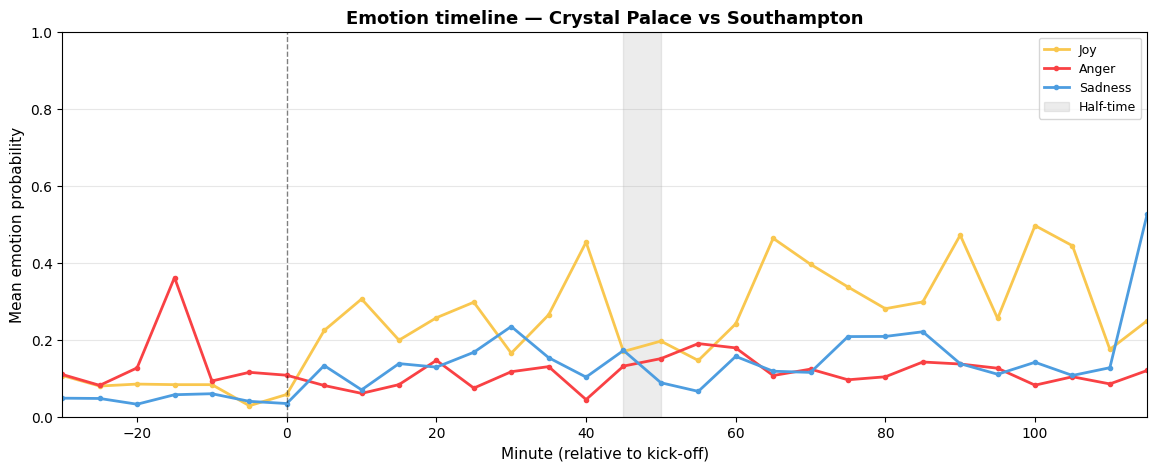

In [6]:
# ── 5. Visualise a single match ───────────────────────────────────────────
# Pick the match with the most tweet windows
top_fixture = aligned.groupby("fixture_id")["window_5min"].count().idxmax()
print(f"Visualising fixture_id: {top_fixture}")

emotion_cols = [c for c in ["joy","anger","sadness","fear","surprise","disgust"]
                if c in aligned.columns]

fig = plot_emotion_timeline(
    window_df=aligned,
    fixture_id=top_fixture,
    emotion_cols=emotion_cols,
    save_path=f"{OUTPUT_DIR}/emotion_timeline_example.png"
)
plt.show()

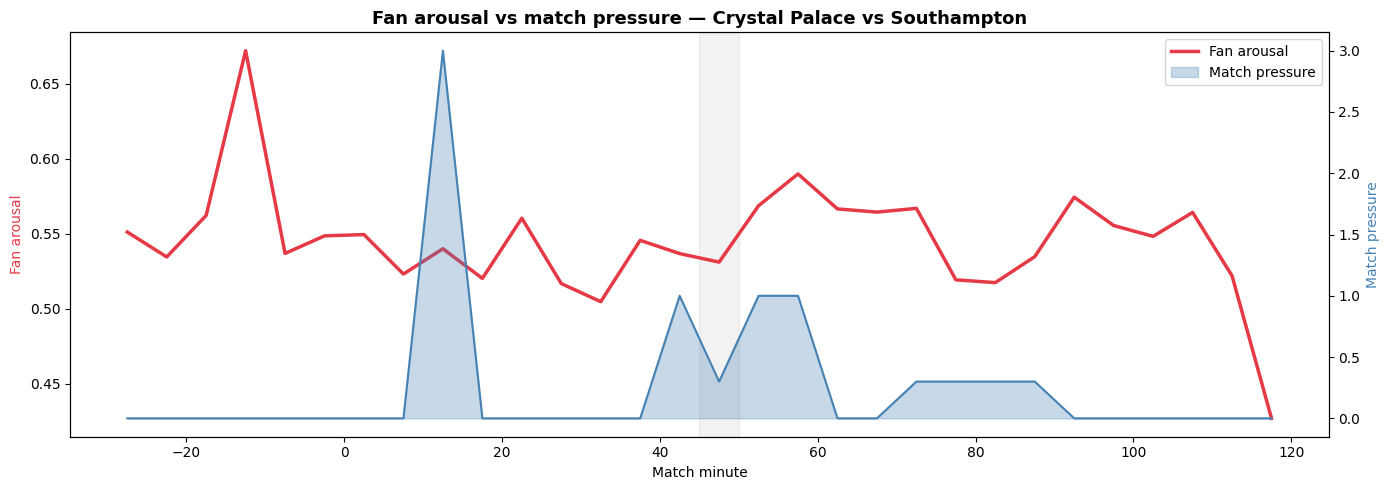

In [7]:
# Dual-axis: arousal + match pressure for the same match
match_data = aligned[aligned["fixture_id"] == top_fixture].sort_values("window_5min")

if "mean_arousal" not in match_data.columns:
    print("mean_arousal not found — make sure notebook 02 completed and tweets_with_emotions.csv was saved.")
    print(f"Available columns: {match_data.columns.tolist()}")
else:
    fig, ax1 = plt.subplots(figsize=(14, 5))
    ax2 = ax1.twinx()

    ax1.plot(match_data["window_5min"] + 2.5, match_data["mean_arousal"],
             color="#e63946", linewidth=2.5, label="Fan arousal")
    ax2.fill_between(match_data["window_5min"] + 2.5, match_data["mean_pressure"],
                     alpha=0.3, color="steelblue", label="Match pressure")
    ax2.plot(match_data["window_5min"] + 2.5, match_data["mean_pressure"],
             color="steelblue", linewidth=1.5)

match_name = match_data["match"].iloc[0] if "match" in match_data.columns else str(top_fixture)
ax1.set_title(f"Fan arousal vs match pressure — {match_name}", fontsize=13, fontweight="bold")
ax1.set_xlabel("Match minute")
ax1.set_ylabel("Fan arousal", color="#e63946")
ax2.set_ylabel("Match pressure", color="steelblue")
ax1.axvspan(45, 50, alpha=0.1, color="grey")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/arousal_vs_pressure_example.png", dpi=150)
plt.show()


In [8]:
# ── 6. Export ─────────────────────────────────────────────────────────────
aligned.to_csv(f"{OUTPUT_DIR}/aligned_windows.csv", index=False)
print(f"Exported → {OUTPUT_DIR}/aligned_windows.csv")

Exported → ../outputs/aligned_windows.csv
